In [101]:
import numpy as np
import random
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
from scipy.optimize import curve_fit
import warnings

Pm = 907 /8 * 1e3 # коэффициент перевода из пкс в м

warnings.filterwarnings("ignore")

In [59]:
time = []
I = []
U = []
bord = []
for i in range(1, 10):
    path = "electro/c3/speed_{}.txt".format(i)
    with open(path, encoding="latin-1") as f:
        lines = f.readlines()[7:]
        i = []
        u = []
        for line in lines:
            mnt = list(map(float, line.strip().split()))
            u.append(mnt[1])
            i.append(mnt[2])
        i = np.array(i)
        u = np.array(u)
        I.append(i)
        U.append(u)


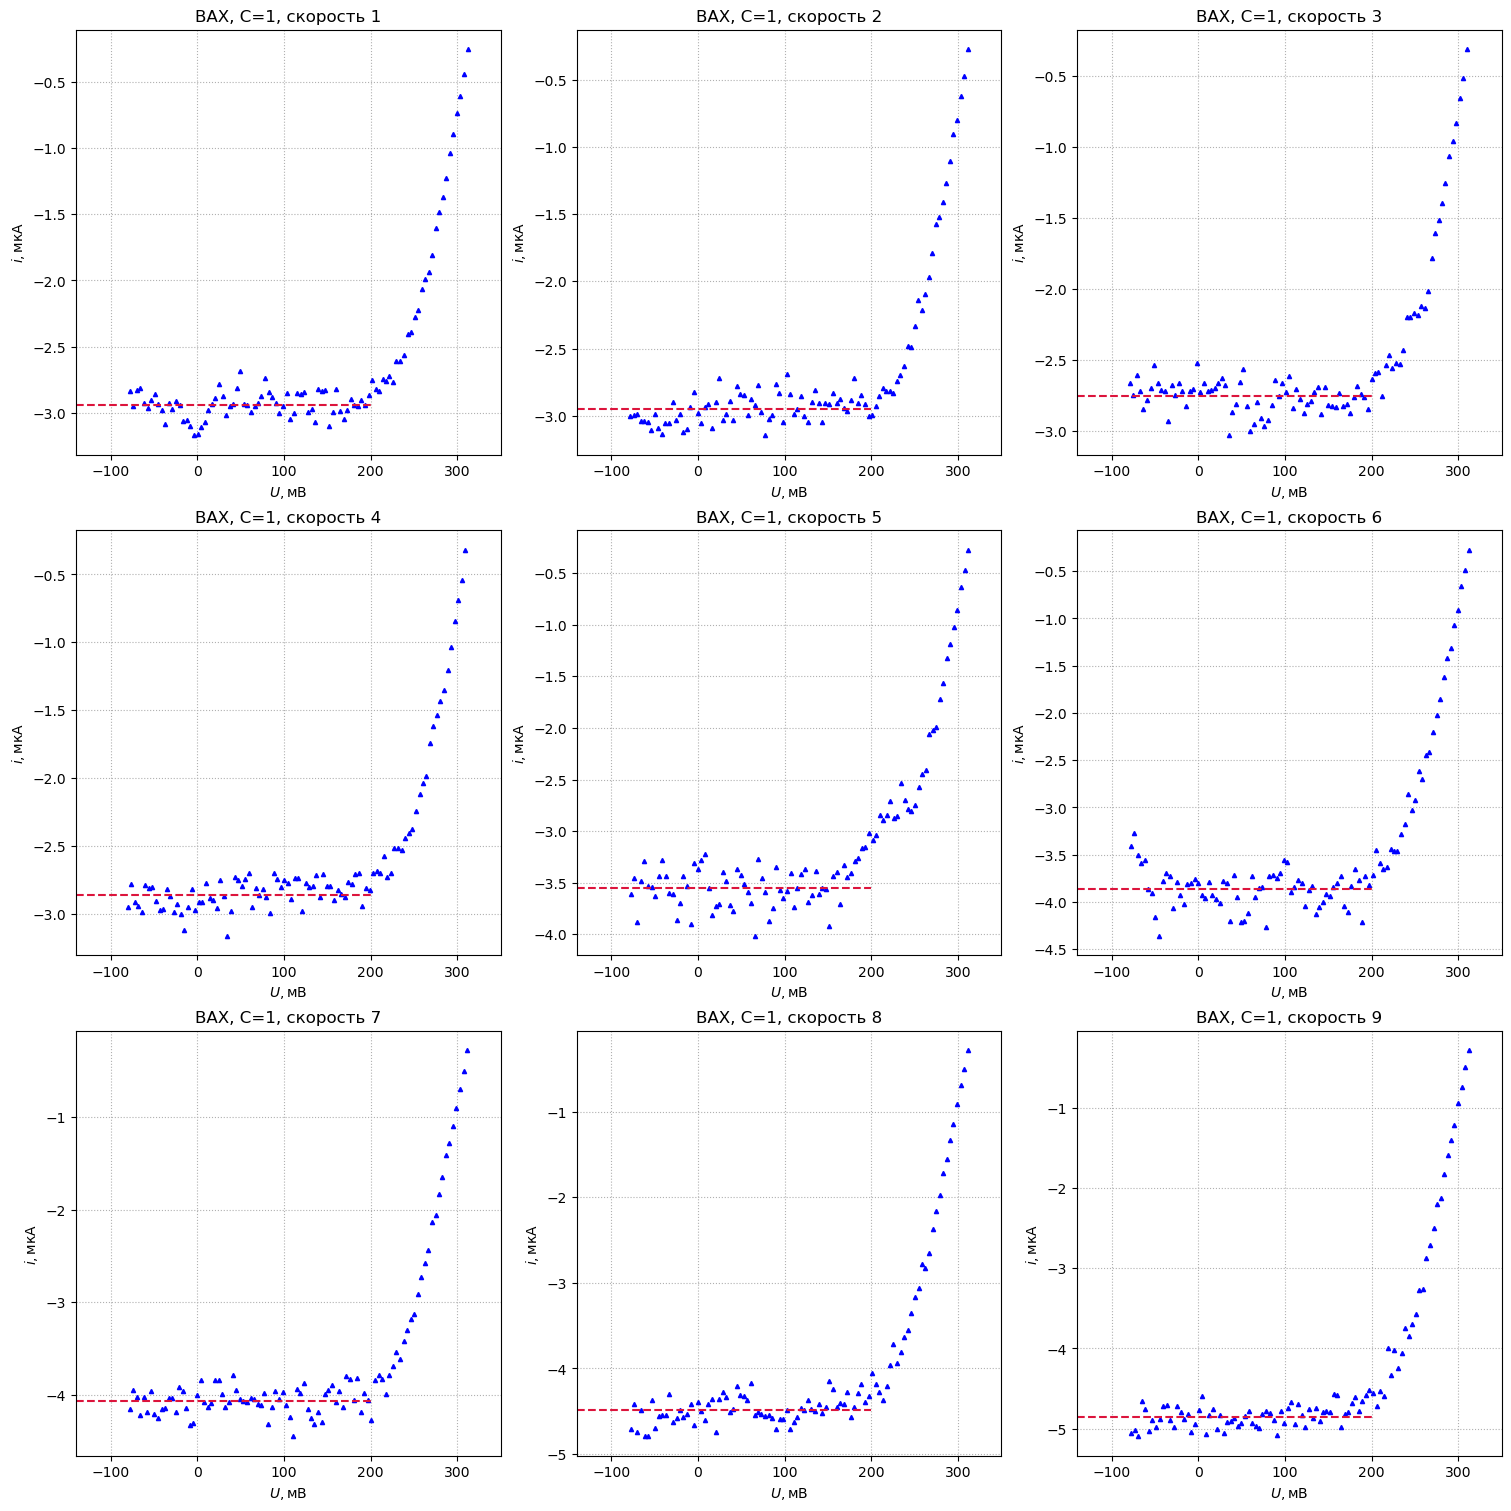

In [69]:
i_lim = []
fig, axs = plt.subplots(3, 3, figsize=(15, 15), layout='constrained')
plt.xlim(-120, 300)
for ax, idx in zip(axs.flat, range(0, 9)):
    # mean_i = np.mean(I[idx][19:])
    mean_i = np.mean(I[idx][34:])
    i_lim.append(-mean_i)
    ax.set_title(f'ВАХ, C=1, скорость {idx+1}')
    ax.plot(U[idx], I[idx], '^', markersize=3, lw=0.01, color="b")
    ax.plot([-140, 200], [mean_i, mean_i], linestyle="--", alpha=1, color="crimson")
    ax.set_xlabel(r'$U, \text{мВ}$', size=10), ax.set_ylabel(r'$i, \text{мкА}$', size=10)
    ax.grid(ls=':')
    ax.set_xlim(-140, 350)

### Вывод

In [102]:
params = []
for i in range(1, 10):
    path = "images/{}/Log.txt".format(i)
    with open(path, encoding="latin-1") as f:
        lines = f.readlines()
        R = float(lines[9].strip().split()[1])
        a = float(lines[11].strip().split()[2])
        b = float(lines[12].strip().split()[2])
        c = -float(lines[13].strip().split()[2])
        params.append([R, a,  b, c])

In [103]:
params

[[0.99899, 254.93565, 0.14047, 6.89734e-05],
 [0.99734, 257.26161, 0.13484, 7.04517e-05],
 [0.9983, 224.58504, 0.20408, 9.7477e-05],
 [0.99271, 260.6765, 0.35265, 0.00018877],
 [0.99438, 270.75651, 0.60233, 0.00032032],
 [0.99934, 388.50975, 0.74296, 0.00042054],
 [0.99506, 423.45928, 1.16398, 0.00066568],
 [0.9977, -102.60253, 1.81074, 0.00088102],
 [0.98954, -406.6328, 2.84608, 0.0014883]]

In [110]:
omega = []
for i in params:
    omega.append(np.sqrt(2*9.81*i[-1]*Pm))

In [113]:
for i in omega:
    print(round(i, 2), " & ", end="")

1.97  & 1.99  & 2.34  & 3.26  & 4.25  & 4.87  & 6.12  & 7.05  & 9.16  & 

In [112]:
omega = np.array(omega) / 6.283

In [106]:
omega

array([1.97143249, 1.99244724, 2.34364684, 3.26142638, 4.24847552,
       4.86793474, 6.12454523, 7.04585945, 9.15769832])

In [99]:
def linear(x, a, b):
    return a*x + b

args, _ = curve_fit(linear, 1 / np.sqrt(omega[5:]), 1 / np.array(i_lim[5:]))

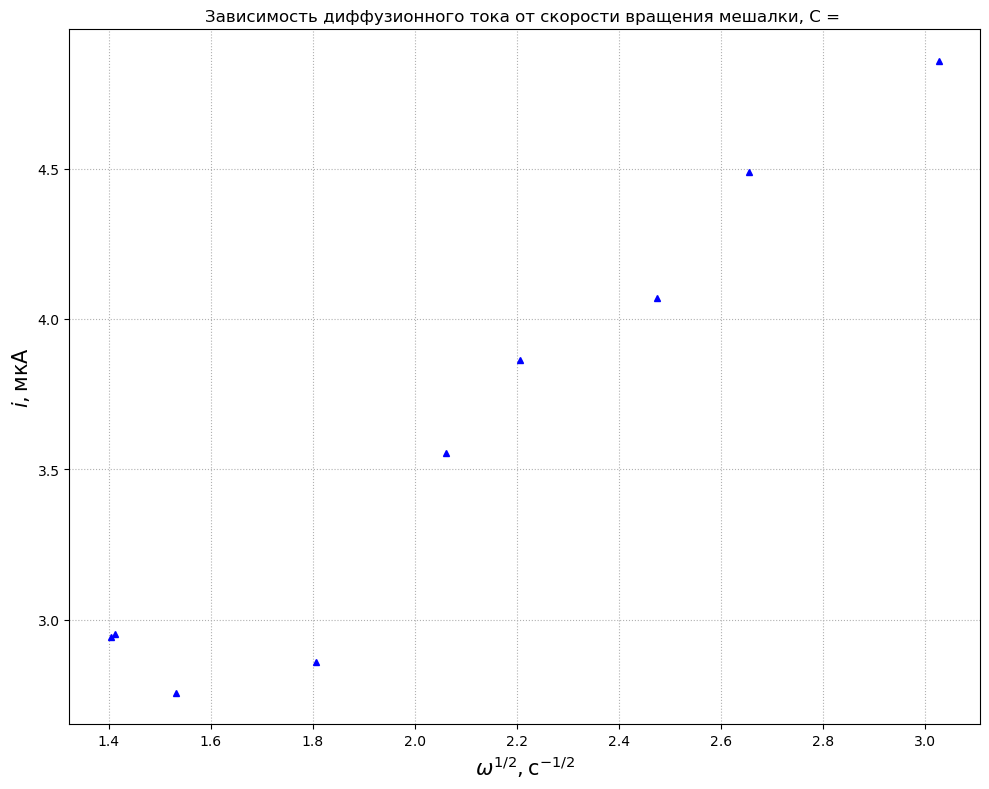

In [100]:
fig, ax = plt.subplots(figsize=(10, 8), layout="tight")
ax.plot(np.sqrt(omega), np.array(i_lim), '^', markersize=5, lw=0.01, color="b")
# ax.plot([0, 0.18], linear(np.array([0, 0.18]), *args), linestyle="--", alpha=1, color="crimson")
plt.xlabel(r'$\omega^{1/2}, \text{c}^{-1/2}$', size=15), plt.ylabel(r'$i, \text{мкА}$', size=15)
plt.title("Зависимость диффузионного тока от скорости вращения мешалки, С = ")
# plt.xlim(0, 0.3)
# plt.ylim(0, 1.4)
ax.grid(ls=':')